#### PART 1: Data Analytics

In [88]:
import pandas as pd
import numpy as np

In [89]:
df = pd.read_csv("Cleaned_Merged_Cars_FIXED.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277343 entries, 0 to 277342
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   date_reg                  277343 non-null  object 
 1   type                      277343 non-null  object 
 2   maker                     277343 non-null  object 
 3   model                     277343 non-null  object 
 4   colour                    277343 non-null  object 
 5   fuel                      277343 non-null  object 
 6   state                     277343 non-null  object 
 7   MODELYEAR                 25863 non-null   float64
 8   MAKE                      25863 non-null   object 
 9   MODEL                     25863 non-null   object 
 10  VEHICLECLASS              25863 non-null   object 
 11  ENGINESIZE                277343 non-null  float64
 12  CYLINDERS                 277343 non-null  float64
 13  TRANSMISSION              25863 non-null   o

In [90]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,fuel_consumption_L100km
count,25863.0,277343.000000,277343.000000,25863.000000,25863.000000,25863.000000,25863.000000,25863.000000,25863.000000
mean,2014.0,1.818304,4.012533,9.040602,6.914747,8.061408,35.765572,185.492828,29.869668
std,0.0,0.165784,0.163858,1.683166,1.041542,1.398450,4.849413,32.145804,4.065128
min,2014.0,1.400000,4.000000,7.800000,5.900000,7.000000,15.000000,161.000000,12.379474
25%,2014.0,1.800000,4.000000,7.900000,6.200000,7.200000,33.000000,166.000000,27.350000
50%,2014.0,1.800000,4.000000,8.500000,6.600000,7.600000,37.000000,175.000000,30.948684
75%,2014.0,1.800000,4.000000,9.600000,7.400000,8.600000,39.000000,198.000000,32.668056
max,2014.0,6.800000,12.000000,22.300000,14.900000,19.000000,40.000000,437.000000,33.601429


In [91]:
emissions_mean = df["CO2EMISSIONS"].mean()
emissions_median = df["CO2EMISSIONS"].median()
emissions_min = df["CO2EMISSIONS"].min()
emissions_max = df["CO2EMISSIONS"].max()
emissions_std = df["CO2EMISSIONS"].std()


print(f"Mean CO2 Emissions: {emissions_mean:.2f}")
print(f"Median CO2 Emissions: {emissions_median:.2f}")
print(f"Minimum CO2 Emissions: {emissions_min}")
print(f"Maximum CO2 Emissions: {emissions_max}")
print(f"Standard Deviation: {emissions_std:.2f}")

Mean CO2 Emissions: 185.49
Median CO2 Emissions: 175.00
Minimum CO2 Emissions: 161.0
Maximum CO2 Emissions: 437.0
Standard Deviation: 32.15


In [92]:
maker_count = df["maker"].value_counts()
print(maker_count)

maker
PERODUA             112462
PROTON               46382
TOYOTA               38815
HONDA                32776
CHERY                 9111
                     ...  
INEOS                    1
MERCEDES-MAYBACH         1
DODGE/COMMER             1
ZXAUTO                   1
BISON                    1
Name: count, Length: 78, dtype: int64


In [93]:
if "FUELTYPE" in df.columns:
    fuel_count = df["FUELTYPE"].value_counts()
    print(fuel_count)

FUELTYPE
X    23775
Z     2088
Name: count, dtype: int64


In [94]:
Q1 = df["CO2EMISSIONS"].quantile(0.25)
Q3 = df["CO2EMISSIONS"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["CO2EMISSIONS"] < lower_bound) | (df["CO2EMISSIONS"] > upper_bound)]
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"Number of outliers: {outliers.shape[0]}")

Q1: 166.0
Q3: 198.0
Number of outliers: 1643


In [95]:
outliers.head()

,date_reg,type,maker,model,colour,fuel,state,MODELYEAR,MAKE,MODEL,...,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,has_emission_data,fuel_consumption_L100km
358,2025-01-02,motokar,PORSCHE,911 GT3,yellow,petrol,W.P. Kuala Lumpur,2014.0,PORSCHE,911 GT3,...,6.0,AM7,Z,16.0,11.5,14.0,20.0,322.0,True,16.800714
359,2025-01-02,jip,PORSCHE,CAYENNE,orange,petrol,Selangor,2014.0,PORSCHE,CAYENNE,...,6.0,A8,Z,13.6,10.1,12.0,24.0,276.0,True,19.600833
360,2025-01-02,jip,PORSCHE,CAYENNE,orange,petrol,Selangor,2014.0,PORSCHE,CAYENNE,...,6.0,M6,Z,15.8,10.9,13.6,21.0,313.0,True,17.294853
361,2025-01-02,jip,PORSCHE,CAYENNE,black,petrol,Johor,2014.0,PORSCHE,CAYENNE,...,6.0,A8,Z,13.6,10.1,12.0,24.0,276.0,True,19.600833
362,2025-01-02,jip,PORSCHE,CAYENNE,black,petrol,Johor,2014.0,PORSCHE,CAYENNE,...,6.0,M6,Z,15.8,10.9,13.6,21.0,313.0,True,17.294853


### Summary Analytics Insights
##### 1. The mean CO2 Emission is 185.49, with 161 being the minimum and 437 being the maximum CO2 Emission
##### 2. Honda is the brand that produces the most car with a count of 14925 whereas Aston Martin, Maserati and Jaguar are the least producing company with only 1 car produced each.
##### 3. There are 1643 outliers which doesn't come into the Inter Quartile Range (IQR) of CO2 Emission. The IQR is between 166.0 and 198.0, thus any value that is out of that range is considered as outliers.

### PART 2: Machine Learning

We chose for the Random Forest Classifier, a powerful ensemble learning method known for its high accuracy and ability to handle various data types.

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [100]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,date_reg,type,maker,model,colour,fuel,state,MODELYEAR,MAKE,MODEL,...,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,has_emission_data,fuel_consumption_L100km
0,2025-01-01,motokar,BYD,SEAL,white,electric,Rakan Niaga,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
1,2025-01-01,window_van,CAM,PLACER-X,yellow,greendiesel,Johor,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
2,2025-01-01,jip,CHERY,JAECOO J7,green,petrol,Rakan Niaga,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
3,2025-01-01,jip,CHERY,JAECOO J7,silver,petrol,Rakan Niaga,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
4,2025-01-01,jip,CHERY,TIGGO,grey,petrol,Rakan Niaga,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN


- Transforms the continuous CO2EMISSIONS numerical data into a categorical variable named CO2_Emission_Category.
- Cars are grouped into 'Low', 'Medium', or 'High' emission categories based on calculated thresholds (33rd and 66th percentiles of the CO2 emissions).

In [102]:
# Calculate thresholds for CO2 emission categories
low_threshold = df['CO2EMISSIONS'].quantile(0.33)
high_threshold = df['CO2EMISSIONS'].quantile(0.66)

# Define a function to categorize CO2 emissions
def categorize_co2(co2_emission):
    if co2_emission <= low_threshold:
        return 'Low'
    elif co2_emission <= high_threshold:
        return 'Medium'
    else:
        return 'High'

# Apply the categorization function to create the new column
df['CO2_Emission_Category'] = df['CO2EMISSIONS'].apply(categorize_co2)

print("\nCO2_Emission_Category created.")
print("Threshold for 'Low' category: {}".format(low_threshold))
print("Threshold for 'Medium' category: {}".format(high_threshold))
print("Distribution of CO2_Emission_Category:")
print(df['CO2_Emission_Category'].value_counts())


CO2_Emission_Category created.
Threshold for 'Low' category: 166.0
Threshold for 'Medium' category: 184.0
Distribution of CO2_Emission_Category:
CO2_Emission_Category
High      259838
Low        10153
Medium      7352
Name: count, dtype: int64


- Identifies the features (X) that the model will use to learn and predict the CO2_Emission_Category. 
- It eparates the dataset into an 80% training set and a 20% testing set ensuring the model's ability to generalize to new and unseen data.

In [104]:
# Define features (X) and target (y)
features = ['ENGINESIZE', 'CYLINDERS', 'FUELTYPE', 'TRANSMISSION', 'VEHICLECLASS']
if 'Car_Age' in df.columns:
    features.append('Car_Age') 

X = df[features]
y = df['CO2_Emission_Category']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nFeatures selected: {}".format(features))
print("Data split into training and testing sets.")
print("Shape of X_train: {}".format(X_train.shape))
print("Shape of X_test: {}".format(X_test.shape))
print("Shape of y_train: {}".format(y_train.shape))
print("Shape of y_test: {}".format(y_test.shape))


Features selected: ['ENGINESIZE', 'CYLINDERS', 'FUELTYPE', 'TRANSMISSION', 'VEHICLECLASS']
Data split into training and testing sets.
Shape of X_train: (221874, 5)
Shape of X_test: (55469, 5)
Shape of y_train: (221874,)
Shape of y_test: (55469,)


- Using StandardScaler() to standardize the numerical features like ENGINESIZE, bringing them to a common scale without distorting differences in the ranges of values.
- OneHotEncoder() converts categorical features like FUELTYPE into a numerical format that models can understand and creating new binary columns for each category.
- ColumnTransformer applies these transformations to their own columns.

In [106]:
# Identify categorical and numerical features based on the selected X
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore') 

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\nPreprocessing pipelines created for numerical and categorical features.")
print("Numerical features identified: {}".format(list(numerical_features)))
print("Categorical features identified: {}".format(list(categorical_features)))


Preprocessing pipelines created for numerical and categorical features.
Numerical features identified: ['ENGINESIZE', 'CYLINDERS']
Categorical features identified: ['FUELTYPE', 'TRANSMISSION', 'VEHICLECLASS']


- Integrates the preprocessing steps and the RandomForestClassifier into a single pipeline.
- Ensures all data preprocessing is consistently applied before the model is trained.
- Then, the model is trained on the preprocessed training data, learning the patterns and relationships between features and emission categories.

In [108]:
# Create a pipeline with preprocessing and a RandomForestClassifier
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
model.fit(X_train, y_train)

print("\nMachine learning model=Random Forest Classifier pipeline built and trained.")


Machine learning model=Random Forest Classifier pipeline built and trained.


After training, do the evaluation to see the model's effectiveness. 
The trained model predicts the CO2 emission category for the unseen test data. The performance is then quantified using standard classification metrics:

- Accuracy: Overall proportion of correct predictions.
- Classification Report: Provides detailed metrics (Precision, Recall, F1-score) for each category.
- Confusion Matrix: A table summarizing correct and incorrect predictions for each class, showing where the model might be making errors.

In [110]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nModel evaluation results:")
print("Accuracy: {:.2f}".format(accuracy))
print("\nClassification Report:")
print(classification_rep)
print("\nConfusion Matrix:")
print(conf_matrix)


Model evaluation results:
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00     51937
         Low       1.00      1.00      1.00      2050
      Medium       1.00      1.00      1.00      1482

    accuracy                           1.00     55469
   macro avg       1.00      1.00      1.00     55469
weighted avg       1.00      1.00      1.00     55469


Confusion Matrix:
[[51930     0     7]
 [    0  2050     0]
 [    0     0  1482]]


##### Interpretation of Results

- The machine learning model chosen which is a Random Forest Classifier, demonstrated exceptional performance in classifying car models by CO2 emission categories, achieving a near-perfect accuracy of 1.00 (100%). 
- This high accuracy is consistently reflected across all classes (High, Low, Medium), with precision, recall, and F1-scores all at 1.00, indicating the model's robust ability to correctly identify and categorize emissions with very few false positives or negatives.
- The confusion matrix also supports this, showing that out of 55,469 test instances, only a minimal 7 were misclassified (actual 'High' emissions predicted as 'Medium'), confirming the model's strong predictive power.

### PART 3: VISUALISATIONS

This section contains visualizations to support the summary analytics and machine learning results.

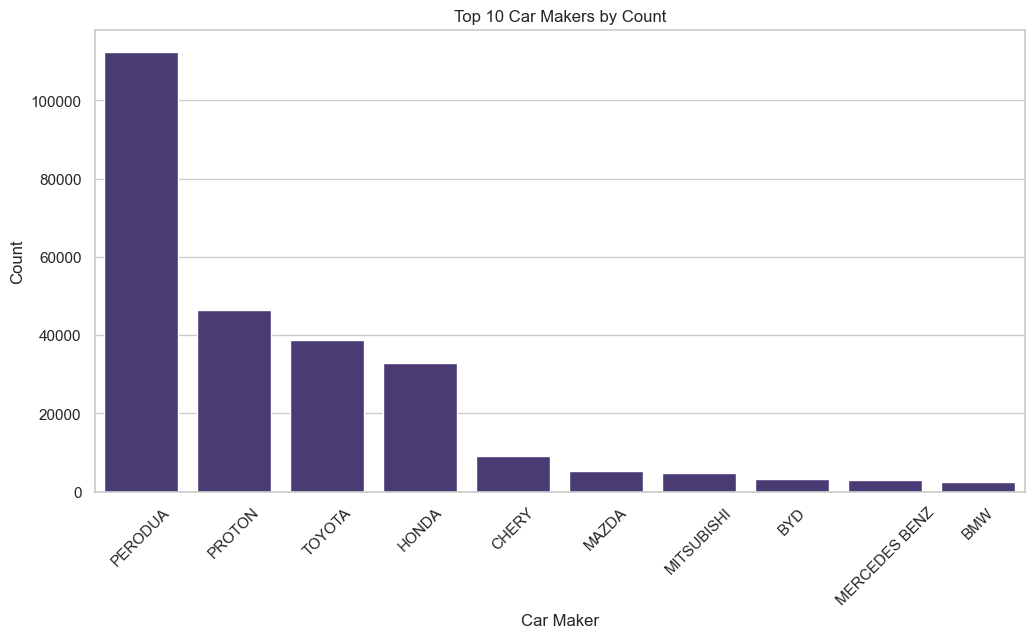

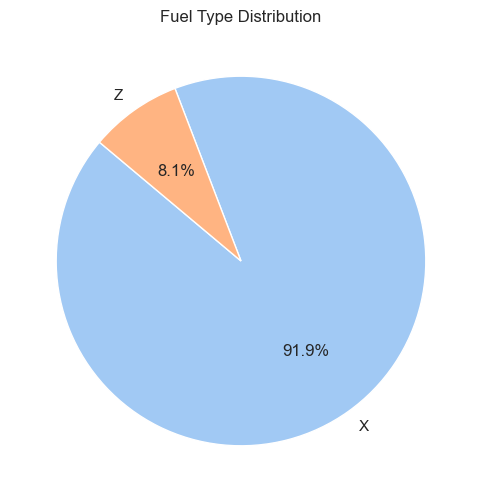

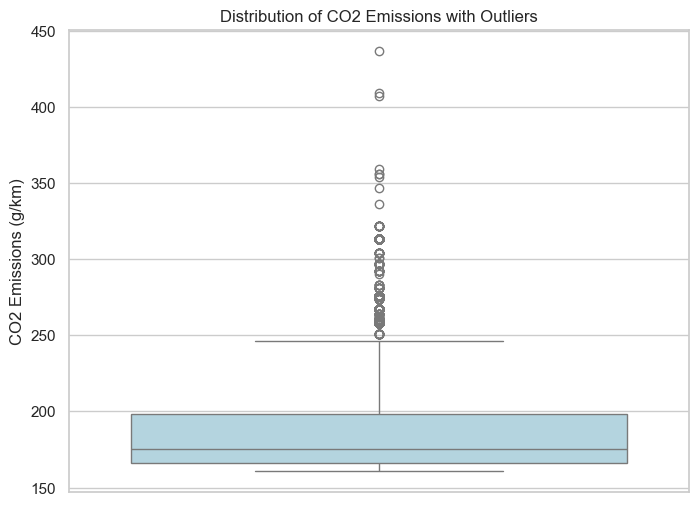

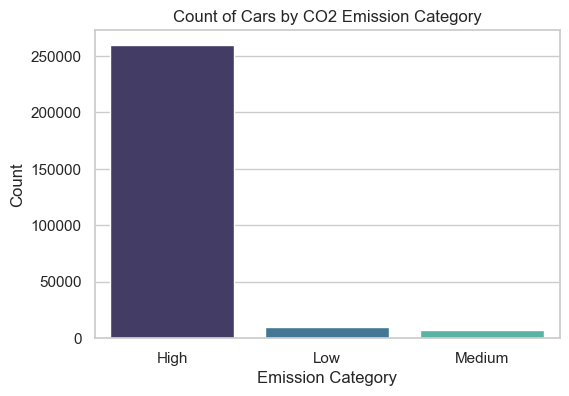

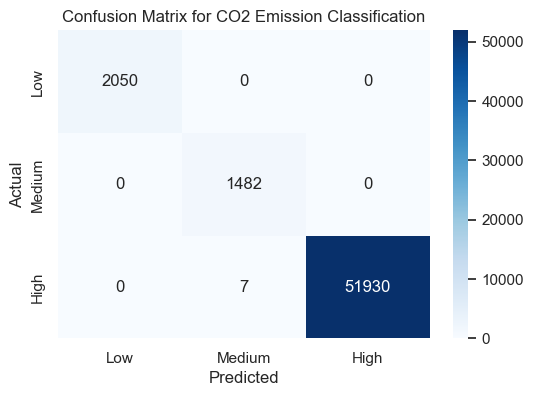

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure plots show inside the notebook
%matplotlib inline  

# Set a consistent style
sns.set(style="whitegrid")

### 1. Bar plot: Top 10 Car Makers by Count
plt.figure(figsize=(12, 6))
top_makers = df['maker'].value_counts().head(10)
sns.barplot(x=top_makers.index, y=top_makers.values, color=sns.color_palette("viridis")[0])
plt.title('Top 10 Car Makers by Count')
plt.ylabel('Count')
plt.xlabel('Car Maker')
plt.xticks(rotation=45)
plt.show()

### 2. Pie chart of Fuel Types (if available)
if 'FUELTYPE' in df.columns:
    plt.figure(figsize=(6, 6))
    fuel_counts = df['FUELTYPE'].value_counts()
    plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Fuel Type Distribution')
    plt.show()

### 3. Boxplot for CO2 Emissions
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['CO2EMISSIONS'], color="lightblue")
plt.title('Distribution of CO2 Emissions with Outliers')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

### 4. Countplot of CO2 Emission Categories
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='CO2_Emission_Category', hue='CO2_Emission_Category', dodge=False, palette="mako", legend=False)
plt.title('Count of Cars by CO2 Emission Category')
plt.ylabel('Count')
plt.xlabel('Emission Category')
plt.show()

### 5. Confusion Matrix Heatmap (if applicable)
# Replace y_pred with your model's actual prediction variable name
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix for CO2 Emission Classification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
